# Imports

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
# import tensorflow_probability as tfp
import keras_opt
from keras_opt import scipy_optimizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [3]:
print(f'Version: {keras_opt.__version__}')
keras_opt.verify_fix()
# print(f'Version: {keras.__version__}')

Version: 0.0.5
keras-opt v0.0.5 loaded correctly
Recursion fix is PRESENT: using model.call()


True

# Using Basic Data

## Data Loading/Preparation

In [ ]:
data = pd.read_csv('../datasets/assignment02_californiahousing.csv')
X = data.drop(columns=['MedHouseVal'])
y = data['MedHouseVal']
predictors = ["MedInc","HouseAge","AveRooms","AveBedrms","Population","AveOccup","Latitude","Longitude"]

preprocessor = make_column_transformer(
        (StandardScaler(), predictors),
        remainder='passthrough')
    

X_transformed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=3619)  

## Prelim Model

In [ ]:
model = keras.Sequential([ 
    keras.layers.Dense(512, activation='relu', input_shape=(8,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

model.compile(loss='mean_squared_error', 
              optimizer='adam', # keras.optimizers.adam(0.001) for example if I want to define a LR, otherwise it's pre-defined
              metrics=['mae'])

history_adam = model.fit(X_train, y_train,
                           epochs=20, verbose=1, batch_size=256, # larger batch size for larger datasets... right?
                           validation_data=(X_test, y_test))

## L-BFGS Optimizer (via keras_opt)

In [ ]:
# runtime: 107 minutes (20 epochs)
# runtime: 18s (2 epochs)
model2 = keras.Sequential([ 
    keras.layers.Dense(512, activation='relu', input_shape=(8,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

model2.compile(loss='mean_squared_error', 
             metrics=['mae'])

model2.train_function = scipy_optimizer.make_train_function(
            model2, maxiter=300)

history_lfbgs = model2.fit(X_train, y_train,
                           epochs=2, verbose=1, batch_size=2048,
                           validation_data=(X_test, y_test))

## Plotting Performance

In [ ]:
model_history = {"1st Order":history_adam.history,
                 "2nd Order":history_lfbgs.history}

# Loss
plt.figure(figsize=(10, 4))
for name in model_history:
    plt.plot(model_history[name]['loss'], label=f'{name}')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log') # log scale for better visualization. Without this, they all just collapsed to flat lines and it was impossible to distinguish
plt.legend()
plt.show()

# # Training MAE
# plt.figure(figsize=(10, 4))
# for name in model_history:
#     plt.plot(model_history[name]['mae'], label=f'{name}')
# plt.title("Training MAE")
# plt.xlabel("Epoch")
# plt.ylabel("MAE")
# plt.yscale('log')
# plt.legend()
# plt.show()

# Validation MAE
plt.figure(figsize=(10, 4))
for name in model_history:
    plt.plot(model_history[name]['val_mae'], label=f'{name}')
plt.title("Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.yscale('log')
plt.legend()
plt.show()

# Validation Loss
plt.figure(figsize=(10, 4))
for name in model_history:
    plt.plot(model_history[name]['val_loss'], label=f'{name}')
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log')
plt.legend()
plt.show()

# Using Stock Data

## Data Loading/Preparation

In [4]:
data2 = pd.read_csv('../datasets/features_with_next_prices_clean.csv')
data2.dropna(inplace = True)
data2.reset_index(inplace = True)
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76469 entries, 0 to 76468
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   index                        76469 non-null  int64  
 1   date                         76469 non-null  object 
 2   return                       76469 non-null  float64
 3   high_open_ratio              76469 non-null  float64
 4   open_low_ratio               76469 non-null  float64
 5   high_close_ratio             76469 non-null  float64
 6   volatility_by_candle_number  76469 non-null  float64
 7   weekday                      76469 non-null  int64  
 8   volume                       76469 non-null  float64
 9   candle_direction             76469 non-null  float64
 10  earning_moment               76469 non-null  int64  
 11  rolling_std_return           76469 non-null  float64
 12  true_range                   76469 non-null  float64
 13  ATR             

In [5]:
X = data2.drop(columns=['index', 'date', 'candle_direction', 'tokenId', 'open_next', 'close_next'])
y = data2['open_next'].values.reshape(-1, 1)
contin = ['volatility_by_candle_number', 'volume',
          'rolling_std_return', 'true_range', 'ATR', 'volume_delta', 'volume_per_range', 'vix', 
          'amzn_vix_proxy', 'iv_delta', 'put_spread', 'call_spread', 'rsi', 'macd', 'return']
categorical = ['weekday', 'earning_moment', 'volume_spike']


preprocessor = make_column_transformer(
    (OneHotEncoder(sparse_output=False, drop="first"), categorical),
    remainder="passthrough"
)

tf.keras.backend.set_floatx('float64')
# X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=3619) 
n = len(X)
split_idx = int(n * 0.8)   # 80% train / 20% test for chronological split



X_train_raw = X[:split_idx]
X_test_raw  = X[split_idx:]
y_train_raw = y[:split_idx]
y_test_raw  = y[split_idx:]



scaler = StandardScaler()
y_train = scaler.fit_transform(y_train_raw)
y_test = scaler.transform(y_test_raw)
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)


X_train64 = X_train.astype('float64')
X_test64 = X_test.astype('float64')
y_train64 = y_train.astype('float64')
y_test64 = y_test.astype('float64')
num_features = X_train.shape[1]

## Prelim Model

In [6]:
tf.keras.backend.clear_session() # if necessary to remove float64
tf.keras.backend.set_floatx('float32')

In [7]:
model3 = keras.Sequential([ 
    keras.layers.Dense(512, activation='relu', input_shape=(num_features,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

model3.compile(loss='mean_squared_error',
               optimizer='adam',
               metrics=['mae'])

history_adam_stocks = model3.fit(X_train, y_train,
                           epochs=20, verbose=1, batch_size=256, # larger batch size for larger datasets... right?
                           validation_data=(X_test, y_test))

Epoch 1/20
239/239 [==============================] - 1s 4ms/step - loss: 0.0251 - mae: 0.0814 - val_loss: 0.0047 - val_mae: 0.0483
Epoch 2/20
239/239 [==============================] - 1s 4ms/step - loss: 0.0029 - mae: 0.0344 - val_loss: 0.0025 - val_mae: 0.0265
Epoch 3/20
239/239 [==============================] - 1s 4ms/step - loss: 0.0024 - mae: 0.0306 - val_loss: 0.0017 - val_mae: 0.0220
Epoch 4/20
239/239 [==============================] - 1s 4ms/step - loss: 0.0019 - mae: 0.0269 - val_loss: 0.0019 - val_mae: 0.0230
Epoch 5/20
239/239 [==============================] - 1s 4ms/step - loss: 0.0018 - mae: 0.0262 - val_loss: 0.0014 - val_mae: 0.0162
Epoch 6/20
239/239 [==============================] - 1s 4ms/step - loss: 0.0016 - mae: 0.0239 - val_loss: 0.0018 - val_mae: 0.0237
Epoch 7/20
239/239 [==============================] - 1s 5ms/step - loss: 0.0014 - mae: 0.0230 - val_loss: 0.0012 - val_mae: 0.0173
Epoch 8/20
239/239 [==============================] - 2s 7ms/step - loss: 0.

## L-BFGS Optimizer (via keras_opt)

In [8]:
tf.keras.backend.clear_session()
tf.keras.backend.set_floatx('float64')

In [9]:
# runtime: 524 minutes (20 epochs)
# runtime: 1-2 minutes (1 epoch)
with tf.device('/CPU:0'): # needed bcs I cannot change GPU settings during runtime
    model4 = keras.Sequential([ 
        keras.layers.Dense(256, activation='relu', input_shape=(num_features,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(1, activation='linear')
    ])

    model4.compile(loss='mean_squared_error', 
                metrics=['mae'])

    model4.train_function = scipy_optimizer.make_train_function(
        model4,
        method="L-BFGS-B",            # top-level OK
        maxiter=300,                  # top-level OK
    )

    history_lfbgs_stocks = model4.fit(X_train64, y_train64,
                            epochs=1, verbose=1, batch_size=2048,
                            validation_data=(X_test64, y_test64))
    second_order_stocks = history_lfbgs_stocks.history

     27/Unknown - 0s 9ms/step - loss: 1.0399

2025-11-15 02:40:09.060661: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


     29/Unknown - 0s 8ms/step - loss: 0.6518

2025-11-15 02:40:09.541817: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


     28/Unknown - 0s 8ms/step - loss: 0.1406

...

     26/Unknown - 0s 9ms/step - loss: 0.0041

2025-11-15 02:40:39.106680: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


     26/Unknown - 0s 8ms/step - loss: 0.0026

2025-11-15 02:41:09.373701: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


30/30 [==============================] - 113s 4s/step - loss: 0.0019 - mae: 0.0244 - val_loss: 2.3341e-04 - val_mae: 0.0119


### Trust-NCG

In [10]:
with tf.device('/CPU:0'): # needed bcs I cannot change GPU settings during runtime
    model5 = keras.Sequential([ 
        keras.layers.Dense(256, activation='relu', input_shape=(num_features,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(1, activation='linear')
    ])

    model5.compile(loss='mean_squared_error', 
                metrics=['mae'])

    model5.train_function = scipy_optimizer.make_train_function(
        model5,
        method="trust-ncg",            # top-level OK
        maxiter=300,
        gtol=1e-05,
        xtol=1e-08
    )

    history_ncg_stocks = model5.fit(X_train64, y_train64,
                            epochs=1, verbose=1, 
                            batch_size=2048,
                            validation_data=(X_test64, y_test64))
    trust_ncg_stocks = history_ncg_stocks.history

     16/Unknown - 0s 11ms/step - loss: 1.0019

/Users/kavinravi/Documents/CPSC_393/.venv311/lib/python3.11/site-packages/scipy/optimize/_minimize.py:806: OptimizeWarning: Unknown solver options: xtol


     29/Unknown - 0s 10ms/step - loss: 0.0921

2025-11-15 02:43:30.548574: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


     29/Unknown - 0s 10ms/step - loss: 0.0025

...

     25/Unknown - 0s 9ms/step - loss: 0.0016

2025-11-15 02:56:51.443648: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


     28/Unknown - 0s 8ms/step - loss: 0.0014

/Users/kavinravi/Documents/CPSC_393/.venv311/lib/python3.11/site-packages/scipy/optimize/_minimize.py:806: RuntimeWarning: A bad approximation caused failure to predict improvement.


         Current function value: 0.001401
         Iterations: 210
         Function evaluations: 212
         Gradient evaluations: 168
         Hessian evaluations: 1272
30/30 [==============================] - 1457s 49s/step - loss: 0.0014 - mae: 0.0213 - val_loss: 0.0012 - val_mae: 0.0147


### Output Metrics (Incase Training Output > 500 Lines)

In [12]:
print("L-BFGS Metrics:")
print(f'Training Loss: {second_order_stocks["loss"]}')
print(f'Training MAE: {second_order_stocks["mae"]}')
print(f'Validation Loss: {second_order_stocks["val_loss"]}')
print(f'Validation MAE: {second_order_stocks["val_mae"]}')
print("\n")
print("Trust-NCG Metrics:")
print(f'Training Loss: {trust_ncg_stocks["loss"]}')
print(f'Training MAE: {trust_ncg_stocks["mae"]}')
print(f'Validation Loss: {trust_ncg_stocks["val_loss"]}')
print(f'Validation MAE: {trust_ncg_stocks["val_mae"]}')


L-BFGS Metrics:
Training Loss: [0.0018673353501098447]
Training MAE: [0.024443256979055535]
Validation Loss: [0.000233410591259212]
Validation MAE: [0.011871587379890294]


Trust-NCG Metrics:
Training Loss: [0.0014017327191044244]
Training MAE: [0.021320463697894736]
Validation Loss: [0.0012135045859280583]
Validation MAE: [0.014737982591536363]


## Plotting Performance

### Performance Metrics
Since the second-order optimizer is only trained on 1 epoch, and doesn't benefit from being trained on more, it won't show on the chart, so only seeing the line corresponding to the 1st order network is normal.

In [ ]:
model_history = {"1st Order":history_adam_stocks.history,
                 "2nd Order":history_lfbgs_stocks.history}

# Loss
plt.figure(figsize=(10, 4))
for name in model_history:
    plt.plot(model_history[name]['loss'], label=f'{name}')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log') # log scale for better visualization. Without this, they all just collapsed to flat lines and it was impossible to distinguish
plt.legend()
plt.show()

# # Training MAE
# plt.figure(figsize=(10, 4))
# for name in model_history:
#     plt.plot(model_history[name]['mae'], label=f'{name}')
# plt.title("Training MAE")
# plt.xlabel("Epoch")
# plt.ylabel("MAE")
# plt.yscale('log')
# plt.legend()
# plt.show()

# Validation MAE
plt.figure(figsize=(10, 4))
for name in model_history:
    plt.plot(model_history[name]['val_mae'], label=f'{name}')
plt.title("Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.yscale('log')
plt.legend()
plt.show()

# Validation Loss
plt.figure(figsize=(10, 4))
for name in model_history:
    plt.plot(model_history[name]['val_loss'], label=f'{name}')
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log')
plt.legend()
plt.show()

### Actual vs Predicted Values

478/478 [==============================] - 0s 204us/step


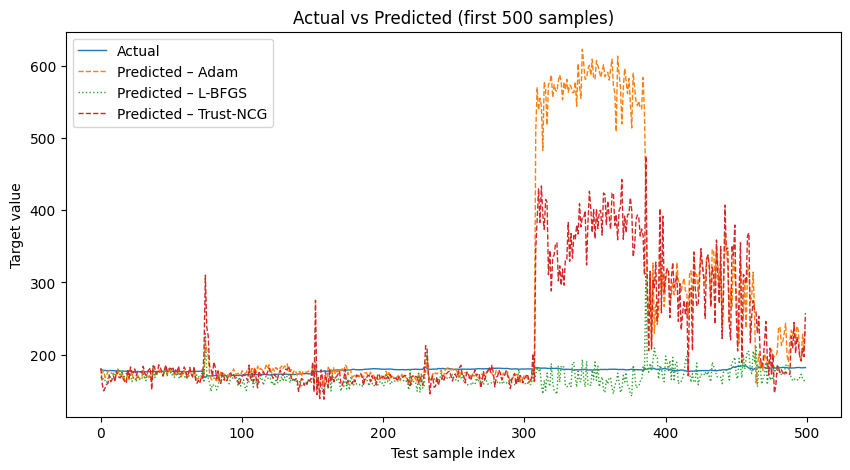

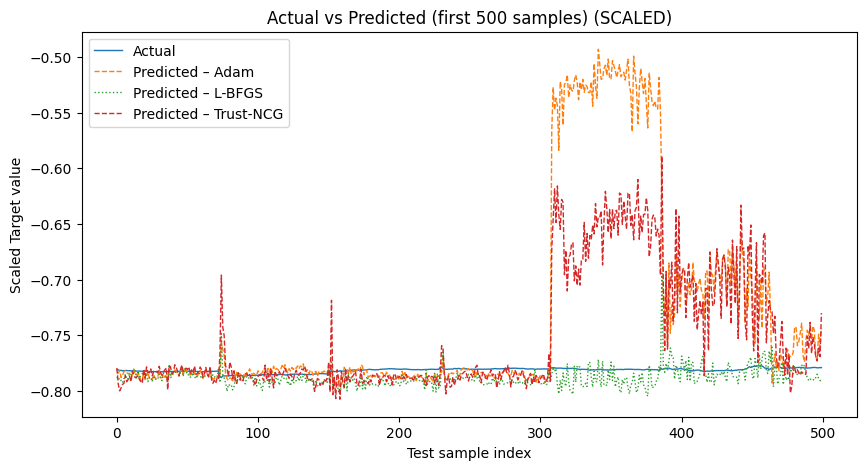

In [14]:
y_pred_adam   = model3.predict(X_test.astype(np.float32))        # likely float32
y_pred_lbfgs  = model4.predict(X_test64)                          # float64
y_pred_ncg    = model5.predict(X_test64)                          # float64

# inverse transform so values are in original scale
y_test_orig = scaler.inverse_transform(y_test64.reshape(-1,1)).ravel()
y_pred_adam_orig = scaler.inverse_transform(y_pred_adam.astype(np.float64)).ravel()
y_pred_lbfgs_orig = scaler.inverse_transform(y_pred_lbfgs).ravel()
y_pred_ncg_orig = scaler.inverse_transform(y_pred_ncg).ravel()

N = len(y_test_orig)
idx = np.arange(N)
# pick first n samples to plot
n_plot = 500
idx_sub = idx[:n_plot]

plt.figure(figsize=(10,5))
plt.plot(idx_sub, y_test_orig[idx_sub], label='Actual', linewidth=1)
plt.plot(idx_sub, y_pred_adam_orig[idx_sub], label='Predicted – Adam', linewidth=1, linestyle='--')
plt.plot(idx_sub, y_pred_lbfgs_orig[idx_sub], label='Predicted – L-BFGS', linewidth=1, linestyle=':')
plt.plot(idx_sub, y_pred_ncg_orig[idx_sub], label='Predicted – Trust-NCG', linewidth=1, linestyle='--')
plt.legend()
plt.title("Actual vs Predicted (first {} samples)".format(n_plot))
plt.xlabel("Test sample index")
plt.ylabel("Target value")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(idx_sub, y_test[idx_sub], label='Actual', linewidth=1)
plt.plot(idx_sub, y_pred_adam[idx_sub], label='Predicted – Adam', linewidth=1, linestyle='--')
plt.plot(idx_sub, y_pred_lbfgs[idx_sub], label='Predicted – L-BFGS', linewidth=1, linestyle=':')
plt.plot(idx_sub, y_pred_ncg[idx_sub], label='Predicted – Trust-NCG', linewidth=1, linestyle='--')
plt.legend()
plt.title("Actual vs Predicted (first {} samples) (SCALED)".format(n_plot))
plt.xlabel("Test sample index")
plt.ylabel("Scaled Target value")
plt.show()

